# Ejercicio 3 — Volatilidad determinista y opción asiática

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos matemáticos — Procesos estocásticos

---

## Objetivo

Para

$$dS_t=rS_tdt+\sigma(t)S_tdW_t,$$

con $\sigma(t)$ determinista:

1. verificar la solución explícita;
2. obtener la fórmula de una call europea;
3. calibrar una volatilidad cuadrática a tres precios de mercado;
4. valorar una call asiática aritmética por simulación exacta de las fijaciones.

La calibración separa dos problemas distintos: primero se extrae la varianza acumulada observada en cada vencimiento; después se ajusta el polinomio de volatilidad. La valoración Monte Carlo incluye antitéticos, variable de control y un contraste independiente.


## Configuración del entorno


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FormatStrFormatter
from scipy.optimize import brentq, root
from scipy.stats import norm, qmc, t as student_t
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
})

OUT = Path("resultados")
OUT.mkdir(exist_ok=True)

S0 = 100.0
K = 100.0
r = 0.01
VENCIMIENTOS = np.array([1.0, 1.25, 2.0])
PRECIOS = np.array([9.55, 12.48, 23.36])
print(f"S0={S0:.0f}, K={K:.0f}, r={r:.2%}")


S0=100, K=100, r=1.00%


---

## Apartado 3.1 — Verificación de la solución

Definimos la varianza acumulada:

$$V(t)=\int_0^t\sigma^2(s)\,ds,$$

y el exponente:

$$A_t=rt-\frac12V(t)+\int_0^t\sigma(s)\,dW_s.$$

La solución propuesta es $S_t=S_0e^{A_t}$. Como $\sigma$ es determinista:

$$dA_t=\left(r-\frac12\sigma^2(t)\right)dt+\sigma(t)dW_t,$$

$$d\langle A\rangle_t=\sigma^2(t)dt.$$

Aplicando Itô a la exponencial:

$$dS_t=S_tdA_t+\frac12S_td\langle A\rangle_t.$$

Los dos términos con $\sigma^2(t)dt/2$ se cancelan y queda:

$$dS_t=rS_tdt+\sigma(t)S_tdW_t.$$

Además, $S_0e^{A_0}=S_0$. Por tanto,

$$\boxed{S_t=S_0\exp\left(rt-\frac12\int_0^t\sigma^2(s)ds+
\int_0^t\sigma(s)dW_s\right)}$$

satisface la ecuación y la condición inicial.


---

## Apartado 3.2 — Precio analítico de una call europea

La integral estocástica es normal porque el integrando es determinista:

$$\int_0^T\sigma(s)dW_s\sim N(0,V(T)).$$

Así:

$$\log S_T\sim N\left(\log S_0+rT-\frac12V(T),\,V(T)\right).$$

Bajo la medida neutral al riesgo, el precio descontado del payoff es:

$$C(0;K,T)=e^{-rT}E[(S_T-K)^+].$$

Integrando la lognormal:

$$\boxed{C=S_0\Phi(d_1)-Ke^{-rT}\Phi(d_2)},$$

$$d_1=\frac{\log(S_0/K)+rT+\frac12V(T)}{\sqrt{V(T)}},
\qquad d_2=d_1-\sqrt{V(T)}.$$

Es Black-Scholes con volatilidad efectiva

$$\sigma_{\mathrm{ef}}(T)=\sqrt{\frac{V(T)}{T}}.$$

La fórmula depende de toda la curva $\sigma(t)$ únicamente a través de la varianza acumulada hasta el vencimiento.


In [2]:
def call_desde_varianza(T, V, S=S0, strike=K, rate=r):
    '''Call europea cuando V es la varianza integrada hasta T.'''
    if V <= 0:
        return max(S - strike * np.exp(-rate*T), 0.0)
    raiz = np.sqrt(V)
    d1 = (np.log(S/strike) + rate*T + 0.5*V) / raiz
    d2 = d1 - raiz
    return S*norm.cdf(d1) - strike*np.exp(-rate*T)*norm.cdf(d2)

# Controles de no arbitraje estático y extracción de V(T) por inversión monótona.
limites_inf = np.maximum(S0 - K*np.exp(-r*VENCIMIENTOS), 0.0)
assert np.all(PRECIOS >= limites_inf) and np.all(PRECIOS <= S0)

VARIANZAS_MERCADO = np.array([
    brentq(lambda V: call_desde_varianza(T, V)-precio, 1e-14, 10.0,
           xtol=1e-14, rtol=1e-14)
    for T, precio in zip(VENCIMIENTOS, PRECIOS)
])
VOL_EFECTIVAS = np.sqrt(VARIANZAS_MERCADO / VENCIMIENTOS)
repricing_iv = np.array([
    call_desde_varianza(T, V)
    for T, V in zip(VENCIMIENTOS, VARIANZAS_MERCADO)
])
assert np.max(np.abs(repricing_iv-PRECIOS)) < 2e-12
assert np.all(np.diff(VARIANZAS_MERCADO) > 0)

tabla_mercado = pd.DataFrame({
    "Precio": PRECIOS,
    "Varianza acumulada V(T)": VARIANZAS_MERCADO,
    "Volatilidad efectiva": VOL_EFECTIVAS,
    "Precio reconstruido": repricing_iv,
    "Error": repricing_iv-PRECIOS,
}, index=VENCIMIENTOS)
tabla_mercado.index.name = "T"
display(tabla_mercado.style.format({
    "Precio": "{:.4f}", "Varianza acumulada V(T)": "{:.10f}",
    "Volatilidad efectiva": "{:.6%}", "Precio reconstruido": "{:.10f}",
    "Error": "{:+.2e}",
}))


,Precio,Varianza acumulada V(T),Volatilidad efectiva,Precio reconstruido,Error
T,,,,,
1.000000,9.5500,0.0521320003,22.832433%,9.5500000000,+3.55e-15
1.250000,12.4800,0.0899877821,26.830994%,12.4800000000,+3.55e-15
2.000000,23.3600,0.3292216020,40.572257%,23.3600000000,+7.11e-15


---

## Apartado 3.3 — Calibración de $\sigma(t)=at^2+bt+c$

Al cuadrar e integrar:

$$V(t)=\frac{a^2}{5}t^5+\frac{ab}{2}t^4+
\frac{b^2+2ac}{3}t^3+bct^2+c^2t.$$

Se resuelve el sistema no lineal:

$$V(T_j;a,b,c)=V_j^{\mathrm{mercado}},\qquad
T_j\in\{1,1.25,2\}.$$

Las ecuaciones son invariantes ante $(a,b,c)\mapsto(-a,-b,-c)$, porque los precios dependen de $\sigma^2$. Además, el sistema puede tener curvas distintas que crucen por cero. Como $\sigma$ representa una volatilidad, imponemos la convención financiera $\sigma(t)\geq0$ en $[0,2]$ y auditamos todos los candidatos reales encontrados.


In [3]:
def varianza_polinomio(t, coef):
    a_, b_, c_ = np.asarray(coef)
    t = np.asarray(t)
    return (
        a_**2 * t**5 / 5.0
        + a_*b_ * t**4 / 2.0
        + (b_**2 + 2.0*a_*c_) * t**3 / 3.0
        + b_*c_ * t**2
        + c_**2 * t
    )

def residuo_calibracion(coef):
    return varianza_polinomio(VENCIMIENTOS, coef) - VARIANZAS_MERCADO

# Búsqueda multistart reproducible para no depender de una única inicialización.
rng_roots = np.random.default_rng(20260301)
inicios = list(rng_roots.uniform(-1.5, 1.5, size=(2_000, 3)))
inicios += [
    np.array([aa, bb, cc], dtype=float)
    for aa in (-1.0, -0.3, 0.0, 0.3, 1.0)
    for bb in (-1.0, -0.3, 0.0, 0.3, 1.0)
    for cc in (-0.8, -0.2, 0.2, 0.8)
]

soluciones = []
for x0 in inicios:
    resultado = root(residuo_calibracion, x0, method="lm")
    x = resultado.x
    if np.max(np.abs(residuo_calibracion(x))) < 1e-10:
        if not any(np.linalg.norm(x-y) < 1e-7 for y in soluciones):
            soluciones.append(x)
soluciones = sorted(soluciones, key=lambda x: tuple(x))

grid = np.linspace(0.0, 2.0, 4_001)
filas = []
for x in soluciones:
    sig = x[0]*grid**2 + x[1]*grid + x[2]
    raices = np.roots(x)
    raices_intervalo = sorted(
        float(z.real) for z in raices
        if abs(z.imag) < 1e-8 and 0.0 <= z.real <= 2.0
    )
    filas.append({
        "a": x[0], "b": x[1], "c": x[2],
        "min sigma [0,2]": sig.min(),
        "max sigma [0,2]": sig.max(),
        "Raíces en [0,2]": ", ".join(f"{z:.6f}" for z in raices_intervalo) or "ninguna",
        "Residual máximo": np.max(np.abs(residuo_calibracion(x))),
    })

tabla_soluciones = pd.DataFrame(filas)
assert len(soluciones) == 4
admisibles = [
    x for x in soluciones
    if np.min(x[0]*grid**2 + x[1]*grid + x[2]) >= -1e-10
]
assert len(admisibles) == 1
coef = admisibles[0]
a, b, c = coef

display(tabla_soluciones.style.format({
    "a": "{:+.12f}", "b": "{:+.12f}", "c": "{:+.12f}",
    "min sigma [0,2]": "{:+.6f}", "max sigma [0,2]": "{:+.6f}",
    "Residual máximo": "{:.2e}",
}))
print("\nSolución no negativa elegida:")
print(f"a = {a:.12f}")
print(f"b = {b:.12f}")
print(f"c = {c:.12f}")



Solución no negativa elegida:
a = 0.049958716872
b = 0.200094751620
c = 0.099881280434


,a,b,c,"min sigma [0,2]","max sigma [0,2]","Raíces en [0,2]",Residual máximo
0,-0.236515911316,+1.019217438337,-0.458508450702,-0.458508,+0.633863,0.510290,5.00e-16
1,-0.049958716872,-0.200094751620,-0.099881280434,-0.699906,-0.099881,ninguna,5.55e-17
2,+0.049958716872,+0.200094751620,+0.099881280434,+0.099881,+0.699906,ninguna,1.11e-16
3,+0.236515911316,-1.019217438337,+0.458508450702,-0.633863,+0.458508,0.510290,1.67e-16


,Mercado,Modelo,Error,sigma(T),"sigma efectiva [0,T]"
T,,,,,
1.000000,9.5500,9.5500000000,+3.55e-15,34.993475%,22.832433%
1.250000,12.4800,12.4800000000,+3.55e-15,42.806022%,26.830994%
2.000000,23.3600,23.3600000000,+2.13e-14,69.990565%,40.572257%


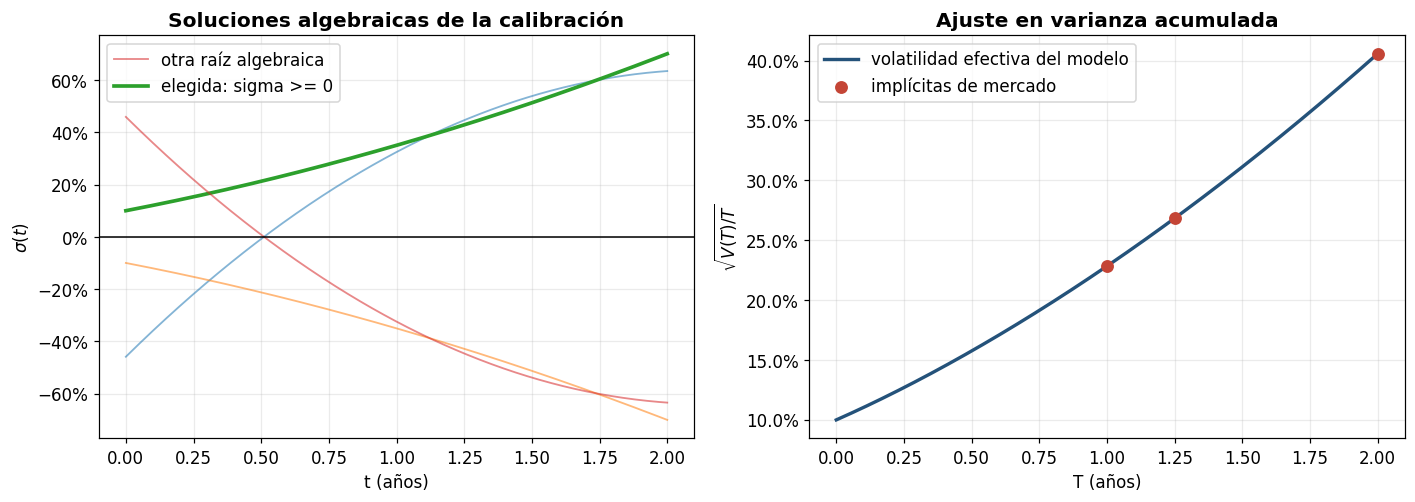

In [4]:
def sigma(t):
    t = np.asarray(t)
    return a*t**2 + b*t + c

V_fit = varianza_polinomio(VENCIMIENTOS, coef)
precios_fit = np.array([
    call_desde_varianza(T, V)
    for T, V in zip(VENCIMIENTOS, V_fit)
])
errores_precio = precios_fit - PRECIOS

assert np.min(sigma(grid)) > 0.0
assert np.all(np.diff(varianza_polinomio(grid, coef)) >= -1e-12)
assert np.max(np.abs(errores_precio)) < 2e-10

tabla_repricing = pd.DataFrame({
    "Mercado": PRECIOS,
    "Modelo": precios_fit,
    "Error": errores_precio,
    "sigma(T)": sigma(VENCIMIENTOS),
    "sigma efectiva [0,T]": np.sqrt(V_fit/VENCIMIENTOS),
}, index=VENCIMIENTOS)
tabla_repricing.index.name = "T"
display(tabla_repricing.style.format({
    "Mercado": "{:.4f}", "Modelo": "{:.10f}", "Error": "{:+.2e}",
    "sigma(T)": "{:.6%}", "sigma efectiva [0,T]": "{:.6%}",
}))

t_plot = np.linspace(0.0, 2.0, 500)
t_eff = np.linspace(1e-4, 2.0, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))

for x in soluciones:
    sig_x = x[0]*t_plot**2 + x[1]*t_plot + x[2]
    es_admisible = np.min(sig_x) >= -1e-10
    axes[0].plot(
        t_plot, sig_x, lw=2.4 if es_admisible else 1.2,
        alpha=1.0 if es_admisible else 0.55,
        label="elegida: sigma >= 0" if es_admisible else "otra raíz algebraica",
    )
axes[0].axhline(0.0, color="black", lw=1)
handles, labels = axes[0].get_legend_handles_labels()
unicos = dict(zip(labels, handles))
axes[0].legend(unicos.values(), unicos.keys())
axes[0].set(title="Soluciones algebraicas de la calibración",
            xlabel="t (años)", ylabel="$\\sigma(t)$")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

vol_ef_curva = np.sqrt(varianza_polinomio(t_eff, coef)/t_eff)
axes[1].plot(t_eff, vol_ef_curva, color="#24527a", lw=2.2,
             label="volatilidad efectiva del modelo")
axes[1].scatter(VENCIMIENTOS, VOL_EFECTIVAS, color="#c44536", s=55,
                zorder=3, label="implícitas de mercado")
axes[1].set(title="Ajuste en varianza acumulada",
            xlabel="T (años)", ylabel="$\\sqrt{V(T)/T}$")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT / "grafico_3c_calibracion_volatilidad.png",
            dpi=150, bbox_inches="tight")
plt.show()


---

## Apartado 3.4 — Valoración de la call asiática

El payoff, pagado en $T_{\mathrm{pago}}=2$, es:

$$\left(\frac14\sum_{i=1}^4S_{t_i}-K\right)^+,$$

con $t=(1.15,1.30,1.60,1.70)$.

La simulación no necesita discretizar toda la SDE. Si

$$Y_i=\int_0^{t_i}\sigma(s)dW_s,$$

entonces el vector $Y$ es normal y:

$$\operatorname{Cov}(Y_i,Y_j)=V(\min(t_i,t_j)).$$

Equivalentemente, los incrementos entre fijaciones son independientes con varianzas

$$\Delta V_i=V(t_i)-V(t_{i-1}),\qquad t_0=0.$$

Simulamos esos incrementos exactamente y usamos:

$$S_{t_i}=S_0\exp\left(rt_i-\frac12V(t_i)+Y_i\right).$$

El descuento es hasta el pago en 2 años, no hasta la última fijación:

$$C_{\mathrm{Asian}}=e^{-2r}E\left[
\left(\frac14\sum_iS_{t_i}-K\right)^+\right].$$


In [5]:
T_FIX = np.array([1.15, 1.30, 1.60, 1.70])
T_PAGO = 2.0
DESCUENTO = np.exp(-r*T_PAGO)
V_FIX = varianza_polinomio(T_FIX, coef)
DELTA_V = np.diff(np.r_[0.0, V_FIX])

assert np.all(DELTA_V > 0)
assert np.all(sigma(T_FIX) > 0)

tabla_fix = pd.DataFrame({
    "sigma(t)": sigma(T_FIX),
    "V(t)": V_FIX,
    "Delta V": DELTA_V,
}, index=T_FIX)
tabla_fix.index.name = "Fijación"
display(tabla_fix.style.format({
    "sigma(t)": "{:.6%}", "V(t)": "{:.10f}", "Delta V": "{:.10f}",
}))

# Precio analítico del promedio geométrico: variable de control.
n_fix = len(T_FIX)
media_log_G = np.mean(np.log(S0) + r*T_FIX - 0.5*V_FIX)
var_log_G = np.minimum.outer(V_FIX, V_FIX).sum() / n_fix**2
sd_log_G = np.sqrt(var_log_G)
d2_G = (media_log_G - np.log(K)) / sd_log_G
d1_G = d2_G + sd_log_G
precio_geo = DESCUENTO * (
    np.exp(media_log_G + 0.5*var_log_G) * norm.cdf(d1_G)
    - K * norm.cdf(d2_G)
)

print(f"Precio analítico de la asiática geométrica de control: {precio_geo:.8f}")


Precio analítico de la asiática geométrica de control: 12.79677073


,sigma(t),V(t),Delta V
Fijación,,,
1.150000,39.606065%,0.0730067303,0.0730067303
1.300000,44.443469%,0.0995035832,0.0264968529
1.600000,54.792720%,0.1734071144,0.0739035312
1.700000,58.442305%,0.2054642135,0.0320570990


In [6]:
def payoffs_antiteticos(z, coef_modelo=coef):
    '''Payoffs descontados por pareja antitética; una fila es una unidad MC.'''
    v = varianza_polinomio(T_FIX, coef_modelo)
    dv = np.diff(np.r_[0.0, v])
    if np.any(dv <= 0):
        raise ValueError("La varianza acumulada no es creciente en las fijaciones")
    resultados = []
    for normales in (z, -z):
        Y = np.cumsum(normales*np.sqrt(dv), axis=1)
        S = S0*np.exp(r*T_FIX - 0.5*v + Y)
        arit = DESCUENTO*np.maximum(S.mean(axis=1)-K, 0.0)
        geom = DESCUENTO*np.maximum(
            np.exp(np.log(S).mean(axis=1))-K, 0.0
        )
        resultados.append((arit, geom))
    payoff_arit = 0.5*(resultados[0][0] + resultados[1][0])
    payoff_geom = 0.5*(resultados[0][1] + resultados[1][1])
    return payoff_arit, payoff_geom

# Piloto independiente para fijar beta sin estimarlo con la muestra de producción.
rng_pilot = np.random.default_rng(20260302)
y_pilot, x_pilot = payoffs_antiteticos(
    rng_pilot.standard_normal((200_000, n_fix))
)
beta_cv = np.cov(y_pilot, x_pilot, ddof=1)[0, 1] / np.var(x_pilot, ddof=1)
corr_cv = np.corrcoef(y_pilot, x_pilot)[0, 1]

# Randomized quasi-Monte Carlo: réplicas Sobol con scrambles independientes.
N_SCRAMBLES = 32
POTENCIA_SOBOL = 16
N_PARES_REPLICA = 2**POTENCIA_SOBOL
medias_plain = []
medias_cv = []
for seed in range(N_SCRAMBLES):
    u = qmc.Sobol(
        d=n_fix, scramble=True, seed=30_000+seed
    ).random_base2(POTENCIA_SOBOL)
    z = norm.ppf(np.clip(u, 1e-15, 1-1e-15))
    y, x = payoffs_antiteticos(z)
    medias_plain.append(y.mean())
    medias_cv.append((y-beta_cv*(x-precio_geo)).mean())

medias_plain = np.array(medias_plain)
medias_cv = np.array(medias_cv)

def resumen_replicas(valores):
    media = valores.mean()
    se = valores.std(ddof=1) / np.sqrt(len(valores))
    critico = student_t.ppf(0.975, df=len(valores)-1)
    return media, se, media-critico*se, media+critico*se

precio_plain, se_plain, lo_plain, hi_plain = resumen_replicas(medias_plain)
precio_asian, se_asian, lo_asian, hi_asian = resumen_replicas(medias_cv)

assert abs(precio_plain-precio_asian) < 5*np.sqrt(se_plain**2+se_asian**2)

print(f"Correlación piloto aritmética-geométrica: {corr_cv:.6f}")
print(f"Beta de control fijada en piloto: {beta_cv:.8f}")
print(f"RQMC + antitéticos ({N_SCRAMBLES} scrambles × "
      f"{2*N_PARES_REPLICA:,} paths):")
print(f"  Sin control: {precio_plain:.8f}  SE(rep)={se_plain:.8f}  "
      f"IC95%=[{lo_plain:.8f}, {hi_plain:.8f}]")
print(f"  Con control: {precio_asian:.8f}  SE(rep)={se_asian:.8f}  "
      f"IC95%=[{lo_asian:.8f}, {hi_asian:.8f}]")


Correlación piloto aritmética-geométrica: 0.997190
Beta de control fijada en piloto: 1.04122446
RQMC + antitéticos (32 scrambles × 131,072 paths):
  Sin control: 13.62196355  SE(rep)=0.00010176  IC95%=[13.62175601, 13.62217108]
  Con control: 13.62180500  SE(rep)=0.00007890  IC95%=[13.62164409, 13.62196591]


### Contraste independiente y riesgo de especificación

Se ejecuta además un Monte Carlo pseudoaleatorio independiente. Su error estándar se calcula sobre las medias de cada pareja antitética, que son las unidades independientes.

El sistema algebraico admite también una curva cuadrática que cruza por cero. No es una volatilidad no negativa y se excluye del caso base, pero reproduce las tres calls europeas. Como genera otras varianzas en las fechas intermedias, permite cuantificar por qué la restricción de signo es material para la asiática.


In [7]:
# Contraste pseudoaleatorio, semilla distinta del piloto y de Sobol.
N_PARES_PRNG = 1_000_000
rng_check = np.random.default_rng(20260303)
y_check, x_check = payoffs_antiteticos(
    rng_check.standard_normal((N_PARES_PRNG, n_fix))
)
y_check_cv = y_check - beta_cv*(x_check-precio_geo)
precio_check = y_check_cv.mean()
se_check = y_check_cv.std(ddof=1) / np.sqrt(N_PARES_PRNG)
lo_check = precio_check - 1.96*se_check
hi_check = precio_check + 1.96*se_check

diferencia_check = precio_check-precio_asian
z_check = diferencia_check / np.sqrt(se_check**2+se_asian**2)
assert abs(z_check) < 4.0

# Elegimos una de las dos raíces que cambian de signo; la otra es su opuesta global.
candidatas_cruce = [
    x for x in soluciones
    if np.min(x[0]*grid**2+x[1]*grid+x[2]) < 0
    and np.max(x[0]*grid**2+x[1]*grid+x[2]) > 0
    and x[2] > 0
]
assert len(candidatas_cruce) == 1
coef_cruce = candidatas_cruce[0]

medias_cruce = []
for seed in range(16):
    u = qmc.Sobol(d=n_fix, scramble=True, seed=40_000+seed).random_base2(15)
    z = norm.ppf(np.clip(u, 1e-15, 1-1e-15))
    y_alt, _ = payoffs_antiteticos(z, coef_modelo=coef_cruce)
    medias_cruce.append(y_alt.mean())
precio_cruce, se_cruce, _, _ = resumen_replicas(np.array(medias_cruce))

print(f"Contraste PRNG + antitéticos + control: {precio_check:.8f}  "
      f"SE={se_check:.8f}  IC95%=[{lo_check:.8f}, {hi_check:.8f}]")
print(f"Diferencia PRNG−RQMC estandarizada: {z_check:+.2f}")
print(f"Curva que cruza cero (rechazada) — asiática: "
      f"{precio_cruce:.6f} ± {1.96*se_cruce:.6f}")
print(f"Impacto frente al caso no negativo: "
      f"{precio_cruce-precio_asian:+.6f} "
      f"({(precio_cruce/precio_asian-1):+.3%})")


Contraste PRNG + antitéticos + control: 13.62209062  SE=0.00105350  IC95%=[13.62002576, 13.62415548]
Diferencia PRNG−RQMC estandarizada: +0.27
Curva que cruza cero (rechazada) — asiática: 13.740158 ± 0.000931
Impacto frente al caso no negativo: +0.118353 (+0.869%)


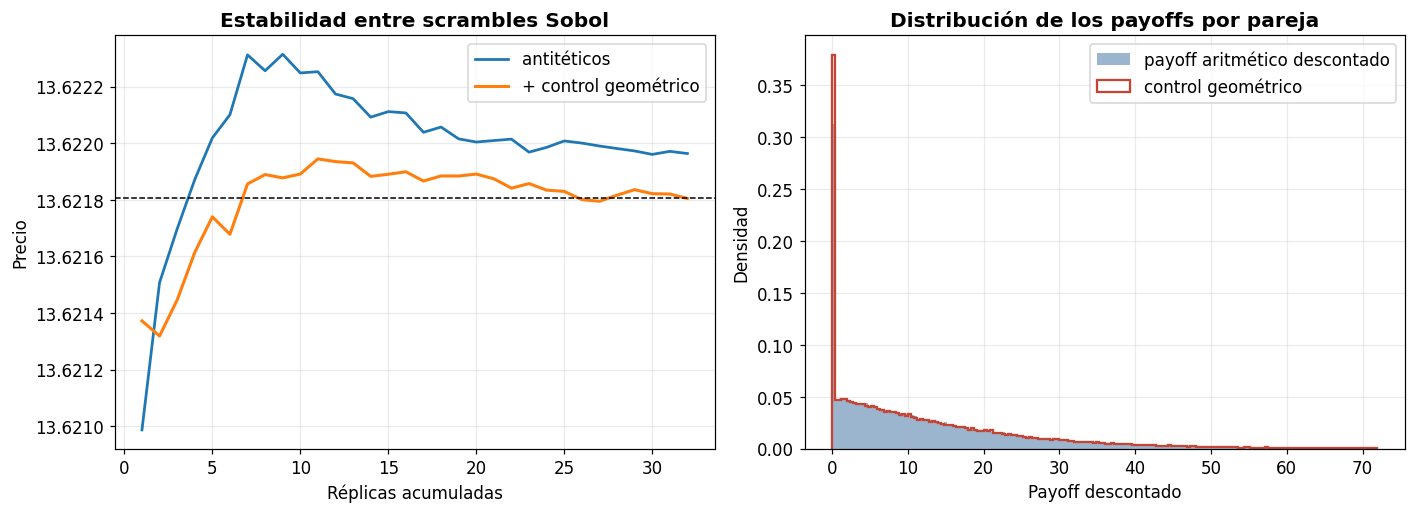

In [8]:
# Evidencia visual: estabilidad entre scrambles y distribución del payoff.
running_plain = np.cumsum(medias_plain) / np.arange(1, N_SCRAMBLES+1)
running_cv = np.cumsum(medias_cv) / np.arange(1, N_SCRAMBLES+1)

n_hist = 150_000
rng_hist = np.random.default_rng(20260304)
y_hist, x_hist = payoffs_antiteticos(
    rng_hist.standard_normal((n_hist, n_fix))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(np.arange(1, N_SCRAMBLES+1), running_plain,
             lw=1.8, label="antitéticos")
axes[0].plot(np.arange(1, N_SCRAMBLES+1), running_cv,
             lw=2.0, label="+ control geométrico")
axes[0].axhline(precio_asian, color="black", ls="--", lw=1)
axes[0].set(title="Estabilidad entre scrambles Sobol",
            xlabel="Réplicas acumuladas", ylabel="Precio")
axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
axes[0].legend()

limite = np.quantile(y_hist, 0.995)
axes[1].hist(y_hist, bins=180, density=True, alpha=0.55,
             range=(0, limite), color="#4c78a8",
             label="payoff aritmético descontado")
axes[1].hist(x_hist, bins=180, density=True, histtype="step", lw=1.5,
             range=(0, limite), color="#c44536",
             label="control geométrico")
axes[1].set(title="Distribución de los payoffs por pareja",
            xlabel="Payoff descontado", ylabel="Densidad")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT / "grafico_3d_valoracion_asiatica.png",
            dpi=150, bbox_inches="tight")
plt.show()


---

## Conclusiones

- Con volatilidad determinista, la distribución europea depende de la curva solo a través de $V(T)=\int_0^T\sigma^2(s)ds$.
- Los tres precios implican una term structure de varianza fuertemente creciente. La calibración cuadrática tiene una única solución no negativa en $[0,2]$ tras fijar la convención de signo.
- Las fijaciones de la asiática se simulan exactamente mediante incrementos de varianza integrada; no existe error de discretización temporal.
- El precio principal usa RQMC, antitéticos y una asiática geométrica de esperanza conocida como control. Un PRNG independiente ofrece un contraste estadístico.
- La alternativa algebraica que cruza por cero demuestra que tres precios europeos no bastan para identificar el precio exótico si no se impone que la volatilidad sea no negativa.


In [9]:
print("=" * 78)
print("RESUMEN EJERCICIO 3")
print("=" * 78)
print(f"Calibración no negativa: a={a:.9f}, b={b:.9f}, c={c:.9f}")
print("Volatilidades efectivas de mercado: "
      + ", ".join(f"{x:.4%}" for x in VOL_EFECTIVAS))
print(f"Error máximo de repricing europeo: {np.max(np.abs(errores_precio)):.2e}")
print(f"Call asiática aritmética: {precio_asian:.6f}")
print(f"IC 95% RQMC por réplicas: [{lo_asian:.6f}, {hi_asian:.6f}]")
print(f"Contraste PRNG: {precio_check:.6f} ± {1.96*se_check:.6f}")
print(f"Sensibilidad a raíz con cruce (rechazada): {precio_cruce:.6f}")


RESUMEN EJERCICIO 3
Calibración no negativa: a=0.049958717, b=0.200094752, c=0.099881280
Volatilidades efectivas de mercado: 22.8324%, 26.8310%, 40.5723%
Error máximo de repricing europeo: 2.13e-14
Call asiática aritmética: 13.621805
IC 95% RQMC por réplicas: [13.621644, 13.621966]
Contraste PRNG: 13.622091 ± 0.002065
Sensibilidad a raíz con cruce (rechazada): 13.740158
